In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"

import torch
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.cuda.amp import GradScaler

# Import utils
from utils.Logger import Logger
from utils.Seed import set_seed
from utils.Splitter import stratified_split
from classes.FeatureDataset.CombinedFeatureDataset import CombinedFeatureDataset
from classes.FeatureDataset.WaveformFeatureDataset import WaveformFeatureDataset
from classes.FeatureDataset.ListDataset import ListDataset

# Import Nes2Net components (baseline)
from classes.models.Nes2Net.model_Nes2Net import WavLMNes2Net
from classes.models.Nes2Net.trainer_Nes2Net import (
    test_nes2net,
    load_model_nes2net,
    test_nes2net_with_loaders
)

seed = 42
set_seed(42)

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = ""

device = "cuda" if torch.cuda.is_available() else "cpu"

batch_size = 32
learning_rate = 0.000001  # 1e-06
epochs = 30

main_keys = [
    "seen all samples",
    "unseen all samples (UID) w/ Google TTS",
    "unseen all samples (UnID)"
]

/raid/m13521069/RawNets-PF/rawnet-pf/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Waveform (Baseline)

In [2]:
# samples will be stored here:
nes2net_waveform_test_samples = {
    "spoof elevenmultilingualv2 converted samples": [],
    "spoof elevenmultilingualv2 tts samples": [],
    "spoof dupdub converted samples": [],
    "spoof dupdub tts samples": [],
    "spoof dupdub notindataset tts samples": [],
    "spoof facebookmms converted samples": [],
    "spoof facebookmms tts samples": [],
    "spoof googletts converted samples": [],
    "spoof googletts tts samples": [],
    "spoof vits converted samples": [],
    "spoof vits tts samples": [],
    "bonafide commonvoice samples": [],
    "bonafide prosa samples": [],
    
    "spoof all samples": [],
    "bonafide all samples": [],
    
    "seen all samples": [],
    "unseen all samples (UID)": [],
    "unseen all samples (UID) w/ Google TTS": [],
    "unseen all samples (UnID)": [],
}

# unseen spoof datasets
nes2net_spoof_elevenmultilingualv2_converted_dir = "test_preprocessed_data/waveform/Spoof/Converted/ElevenMultilingualV2"
nes2net_spoof_elevenmultilingualv2_tts_dir = "test_preprocessed_data/waveform/Spoof/TTS/ElevenMultilingualV2"
nes2net_spoof_dupdub_converted_dir = "test_preprocessed_data/waveform/Spoof/Converted/DupDub"
nes2net_spoof_dupdub_tts_dir = "test_preprocessed_data/waveform/Spoof/TTS/DupDub"
nes2net_spoof_dupdub_notindataset_tts_dir = "test_preprocessed_data/waveform/Spoof/TTS/DupDub-NotInDataset"

# seen spoof datasets
nes2net_spoof_facebookmms_converted_dir = "preprocessed_data/waveform/Spoof/Converted/FacebookMMS"
nes2net_spoof_facebookmms_tts_dir = "preprocessed_data/waveform/Spoof/TTS/FacebookMMS"
nes2net_spoof_googletts_converted_dir = "preprocessed_data/waveform/Spoof/Converted/GoogleTTS"
nes2net_spoof_googletts_tts_dir = "preprocessed_data/waveform/Spoof/TTS/GoogleTTS"
nes2net_spoof_vits_converted_dir = "preprocessed_data/waveform/Spoof/Converted/VITS"
nes2net_spoof_vits_tts_dir = "preprocessed_data/waveform/Spoof/TTS/VITS"

# Bonafide datasets
nes2net_bonafide_commonvoice_dir = "preprocessed_data/waveform/Bonafide/CommonVoice"
nes2net_bonafide_prosa_dir = "preprocessed_data/waveform/Bonafide/Prosa"

## ------------------------------------
## UNSEEN SPOOF DATASETS
## ------------------------------------

# ElevenMultilingualV2 Converted
if os.path.exists(nes2net_spoof_elevenmultilingualv2_converted_dir):
    nes2net_spoof_elevenmultilingualv2_converted_dataset = WaveformFeatureDataset(nes2net_spoof_elevenmultilingualv2_converted_dir, force_label=0)
    nes2net_spoof_elevenmultilingualv2_converted_list = ListDataset([(features, 0) for features, _ in nes2net_spoof_elevenmultilingualv2_converted_dataset.samples])
    nes2net_waveform_test_samples["spoof elevenmultilingualv2 converted samples"].extend(nes2net_spoof_elevenmultilingualv2_converted_list)
    nes2net_waveform_test_samples["spoof all samples"].extend(nes2net_spoof_elevenmultilingualv2_converted_list)
    nes2net_waveform_test_samples["unseen all samples (UID)"].extend(nes2net_spoof_elevenmultilingualv2_converted_list)
    nes2net_waveform_test_samples["unseen all samples (UID) w/ Google TTS"].extend(nes2net_spoof_elevenmultilingualv2_converted_list)

    print(f"Loaded {len(nes2net_spoof_elevenmultilingualv2_converted_list)} samples from {nes2net_spoof_elevenmultilingualv2_converted_dir}")
else:
    print(f"Warning: Directory not found: {nes2net_spoof_elevenmultilingualv2_converted_dir}")

# ElevenMultilingualV2 TTS
if os.path.exists(nes2net_spoof_elevenmultilingualv2_tts_dir):
    nes2net_spoof_elevenmultilingualv2_tts_dataset = WaveformFeatureDataset(nes2net_spoof_elevenmultilingualv2_tts_dir, force_label=0)
    nes2net_spoof_elevenmultilingualv2_tts_list = ListDataset([(features, 0) for features, _ in nes2net_spoof_elevenmultilingualv2_tts_dataset.samples])
    nes2net_waveform_test_samples["spoof elevenmultilingualv2 tts samples"].extend(nes2net_spoof_elevenmultilingualv2_tts_list)
    nes2net_waveform_test_samples["spoof all samples"].extend(nes2net_spoof_elevenmultilingualv2_tts_list)
    nes2net_waveform_test_samples["unseen all samples (UID)"].extend(nes2net_spoof_elevenmultilingualv2_tts_list)
    nes2net_waveform_test_samples["unseen all samples (UID) w/ Google TTS"].extend(nes2net_spoof_elevenmultilingualv2_tts_list)

    print(f"Loaded {len(nes2net_spoof_elevenmultilingualv2_tts_list)} samples from {nes2net_spoof_elevenmultilingualv2_tts_dir}")
else:
    print(f"Warning: Directory not found: {nes2net_spoof_elevenmultilingualv2_tts_dir}")

# DupDub Converted
if os.path.exists(nes2net_spoof_dupdub_converted_dir):
    nes2net_spoof_dupdub_converted_dataset = WaveformFeatureDataset(nes2net_spoof_dupdub_converted_dir, force_label=0)
    nes2net_spoof_dupdub_converted_list = ListDataset([(features, 0) for features, _ in nes2net_spoof_dupdub_converted_dataset.samples])
    nes2net_waveform_test_samples["spoof dupdub converted samples"].extend(nes2net_spoof_dupdub_converted_list)
    nes2net_waveform_test_samples["spoof all samples"].extend(nes2net_spoof_dupdub_converted_list)
    nes2net_waveform_test_samples["unseen all samples (UID)"].extend(nes2net_spoof_dupdub_converted_list)
    nes2net_waveform_test_samples["unseen all samples (UID) w/ Google TTS"].extend(nes2net_spoof_dupdub_converted_list)

    print(f"Loaded {len(nes2net_spoof_dupdub_converted_list)} samples from {nes2net_spoof_dupdub_converted_dir}")
else:
    print(f"Warning: Directory not found: {nes2net_spoof_dupdub_converted_dir}")

# DupDub TTS
if os.path.exists(nes2net_spoof_dupdub_tts_dir):
    nes2net_spoof_dupdub_tts_dataset = WaveformFeatureDataset(nes2net_spoof_dupdub_tts_dir, force_label=0)
    nes2net_spoof_dupdub_tts_list = ListDataset([(features, 0) for features, _ in nes2net_spoof_dupdub_tts_dataset.samples])
    nes2net_waveform_test_samples["spoof dupdub tts samples"].extend(nes2net_spoof_dupdub_tts_list)
    nes2net_waveform_test_samples["spoof all samples"].extend(nes2net_spoof_dupdub_tts_list)
    nes2net_waveform_test_samples["unseen all samples (UID)"].extend(nes2net_spoof_dupdub_tts_list)
    nes2net_waveform_test_samples["unseen all samples (UID) w/ Google TTS"].extend(nes2net_spoof_dupdub_tts_list)

    print(f"Loaded {len(nes2net_spoof_dupdub_tts_list)} samples from {nes2net_spoof_dupdub_tts_dir}")
else:
    print(f"Warning: Directory not found: {nes2net_spoof_dupdub_tts_dir}")

# DupDub NotInDataset TTS
if os.path.exists(nes2net_spoof_dupdub_notindataset_tts_dir):
    nes2net_spoof_dupdub_notindataset_tts_dataset = WaveformFeatureDataset(nes2net_spoof_dupdub_notindataset_tts_dir, force_label=0)
    nes2net_spoof_dupdub_notindataset_tts_list = ListDataset([(features, 0) for features, _ in nes2net_spoof_dupdub_notindataset_tts_dataset.samples])
    nes2net_waveform_test_samples["spoof dupdub notindataset tts samples"].extend(nes2net_spoof_dupdub_notindataset_tts_list)
    nes2net_waveform_test_samples["spoof all samples"].extend(nes2net_spoof_dupdub_notindataset_tts_list)
    nes2net_waveform_test_samples["unseen all samples (UnID)"].extend(nes2net_spoof_dupdub_notindataset_tts_list)
    nes2net_waveform_test_samples["unseen all samples (UID) w/ Google TTS"].extend(nes2net_spoof_dupdub_notindataset_tts_list)

    print(f"Loaded {len(nes2net_spoof_dupdub_notindataset_tts_list)} samples from {nes2net_spoof_dupdub_notindataset_tts_dir}")
else:
    print(f"Warning: Directory not found: {nes2net_spoof_dupdub_notindataset_tts_dir}")

# GoogleTTS TTS
if os.path.exists(nes2net_spoof_googletts_tts_dir):
    dataset_nes2net_spoof_googletts_tts = WaveformFeatureDataset(nes2net_spoof_googletts_tts_dir, force_label=0)
    nes2net_spoof_googletts_tts = ListDataset([(features, 0) for features, _ in dataset_nes2net_spoof_googletts_tts.samples])
    t_gtt, v_gtt, te_gtt = stratified_split(nes2net_spoof_googletts_tts, splits=(0.7, 0.15, 0.15), seed=seed)

    nes2net_spoof_googletts_tts_list = ListDataset([nes2net_spoof_googletts_tts[i] for i in range(len(te_gtt))])
    nes2net_waveform_test_samples["spoof googletts tts samples"].extend(nes2net_spoof_googletts_tts_list)
    nes2net_waveform_test_samples["spoof all samples"].extend(nes2net_spoof_googletts_tts_list)
    nes2net_waveform_test_samples["unseen all samples (UID) w/ Google TTS"].extend(nes2net_spoof_googletts_tts_list)

    print(f"Loaded {len(nes2net_spoof_googletts_tts_list)} samples from {nes2net_spoof_googletts_tts_dir}")
else:
    print(f"Warning: Directory not found: {nes2net_spoof_googletts_tts_dir}")
    
## ------------------------------------
## SEEN SPOOF DATASETS
## ------------------------------------

# FacebookMMS Converted
if os.path.exists(nes2net_spoof_facebookmms_converted_dir):
    dataset_nes2net_spoof_facebookmms_converted = WaveformFeatureDataset(nes2net_spoof_facebookmms_converted_dir, force_label=0)
    nes2net_spoof_facebookmms_converted = ListDataset([(features, 0) for features, _ in dataset_nes2net_spoof_facebookmms_converted.samples])
    t_fmc, v_fmc, te_fmc = stratified_split(nes2net_spoof_facebookmms_converted, splits=(0.7, 0.15, 0.15), seed=seed)

    nes2net_spoof_facebookmms_converted_list = ListDataset([nes2net_spoof_facebookmms_converted[i] for i in range(len(te_fmc))])
    nes2net_waveform_test_samples["spoof facebookmms converted samples"].extend(nes2net_spoof_facebookmms_converted_list)
    nes2net_waveform_test_samples["spoof all samples"].extend(nes2net_spoof_facebookmms_converted_list)
    nes2net_waveform_test_samples["seen all samples"].extend(nes2net_spoof_facebookmms_converted_list)

    print(f"Loaded {len(nes2net_spoof_facebookmms_converted_list)} samples from {nes2net_spoof_facebookmms_converted_dir}")
else:
    print(f"Warning: Directory not found: {nes2net_spoof_facebookmms_converted_dir}")

# FacebookMMS TTS
if os.path.exists(nes2net_spoof_facebookmms_tts_dir):
    dataset_nes2net_spoof_facebookmms_tts = WaveformFeatureDataset(nes2net_spoof_facebookmms_tts_dir, force_label=0)
    nes2net_spoof_facebookmms_tts = ListDataset([(features, 0) for features, _ in dataset_nes2net_spoof_facebookmms_tts.samples])
    t_fmt, v_fmt, te_fmt = stratified_split(nes2net_spoof_facebookmms_tts, splits=(0.7, 0.15, 0.15), seed=seed)
    
    nes2net_spoof_facebookmms_tts_list = ListDataset([nes2net_spoof_facebookmms_tts[i] for i in range(len(te_fmt))])
    nes2net_waveform_test_samples["spoof facebookmms tts samples"].extend(nes2net_spoof_facebookmms_tts_list)
    nes2net_waveform_test_samples["spoof all samples"].extend(nes2net_spoof_facebookmms_tts_list)
    nes2net_waveform_test_samples["seen all samples"].extend(nes2net_spoof_facebookmms_tts_list)

    print(f"Loaded {len(nes2net_spoof_facebookmms_tts_list)} samples from {nes2net_spoof_facebookmms_tts_dir}")
else:
    print(f"Warning: Directory not found: {nes2net_spoof_facebookmms_tts_dir}")

# GoogleTTS Converted
if os.path.exists(nes2net_spoof_googletts_converted_dir):
    dataset_nes2net_spoof_googletts_converted = WaveformFeatureDataset(nes2net_spoof_googletts_converted_dir, force_label=0)
    nes2net_spoof_googletts_converted = ListDataset([(features, 0) for features, _ in dataset_nes2net_spoof_googletts_converted.samples])
    t_gtc, v_gtc, te_gtc = stratified_split(nes2net_spoof_googletts_converted, splits=(0.7, 0.15, 0.15), seed=seed)

    nes2net_spoof_googletts_converted_list = ListDataset([nes2net_spoof_googletts_converted[i] for i in range(len(te_gtc))])
    nes2net_waveform_test_samples["spoof googletts converted samples"].extend(nes2net_spoof_googletts_converted_list)
    nes2net_waveform_test_samples["spoof all samples"].extend(nes2net_spoof_googletts_converted_list)
    nes2net_waveform_test_samples["seen all samples"].extend(nes2net_spoof_googletts_converted_list)

    print(f"Loaded {len(nes2net_spoof_googletts_converted_list)} samples from {nes2net_spoof_googletts_converted_dir}")
else:
    print(f"Warning: Directory not found: {nes2net_spoof_googletts_converted_dir}")

# VITS Converted
if os.path.exists(nes2net_spoof_vits_converted_dir):
    dataset_nes2net_spoof_vits_converted = WaveformFeatureDataset(nes2net_spoof_vits_converted_dir, force_label=0)
    nes2net_spoof_vits_converted = ListDataset([(features, 0) for features, _ in dataset_nes2net_spoof_vits_converted.samples])
    t_vc, v_vc, te_vc = stratified_split(nes2net_spoof_vits_converted, splits=(0.7, 0.15, 0.15), seed=seed)

    nes2net_spoof_vits_converted_list = ListDataset([nes2net_spoof_vits_converted[i] for i in range(len(te_vc))])
    nes2net_waveform_test_samples["spoof vits converted samples"].extend(nes2net_spoof_vits_converted_list)
    nes2net_waveform_test_samples["spoof all samples"].extend(nes2net_spoof_vits_converted_list)
    nes2net_waveform_test_samples["seen all samples"].extend(nes2net_spoof_vits_converted_list)

    print(f"Loaded {len(nes2net_spoof_vits_converted_list)} samples from {nes2net_spoof_vits_converted_dir}")
else:
    print(f"Warning: Directory not found: {nes2net_spoof_vits_converted_dir}")

# VITS TTS
if os.path.exists(nes2net_spoof_vits_tts_dir):
    dataset_nes2net_spoof_vits_tts = WaveformFeatureDataset(nes2net_spoof_vits_tts_dir, force_label=0)
    nes2net_spoof_vits_tts = ListDataset([(features, 0) for features, _ in dataset_nes2net_spoof_vits_tts.samples])
    t_vt, v_vt, te_vt = stratified_split(nes2net_spoof_vits_tts, splits=(0.7, 0.15, 0.15), seed=seed)

    nes2net_spoof_vits_tts_list = ListDataset([nes2net_spoof_vits_tts[i] for i in range(len(te_vt))])
    nes2net_waveform_test_samples["spoof vits tts samples"].extend(nes2net_spoof_vits_tts_list)
    nes2net_waveform_test_samples["spoof all samples"].extend(nes2net_spoof_vits_tts_list)
    nes2net_waveform_test_samples["seen all samples"].extend(nes2net_spoof_vits_tts_list)

    print(f"Loaded {len(nes2net_spoof_vits_tts_list)} samples from {nes2net_spoof_vits_tts_dir}")
else:
    print(f"Warning: Directory not found: {nes2net_spoof_vits_tts_dir}")

### Bonafides
# Bonafide CommonVoice
if os.path.exists(nes2net_bonafide_commonvoice_dir):
    dataset_commonvoice = WaveformFeatureDataset(nes2net_bonafide_commonvoice_dir, force_label=1)
    nes2net_bonafide_commonvoice = ListDataset([(features, 1) for features, _ in dataset_commonvoice.samples])
    t_c, v_c, te_c = stratified_split(nes2net_bonafide_commonvoice, splits=(0.7, 0.15, 0.15), seed=seed)

    nes2net_bonafide_commonvoice_list = ListDataset([nes2net_bonafide_commonvoice[i] for i in range(len(te_c))])
    nes2net_waveform_test_samples["bonafide commonvoice samples"].extend(nes2net_bonafide_commonvoice_list)
    nes2net_waveform_test_samples["bonafide all samples"].extend(nes2net_bonafide_commonvoice_list)
    nes2net_waveform_test_samples["seen all samples"].extend(nes2net_bonafide_commonvoice_list)
    nes2net_waveform_test_samples["unseen all samples (UID)"].extend(nes2net_bonafide_commonvoice_list)
    nes2net_waveform_test_samples["unseen all samples (UID) w/ Google TTS"].extend(nes2net_bonafide_commonvoice_list)
    nes2net_waveform_test_samples["unseen all samples (UnID)"].extend(nes2net_bonafide_commonvoice_list)

    print(f"Loaded {len(nes2net_bonafide_commonvoice_list)} samples from {nes2net_bonafide_commonvoice_dir}")
else:
    print(f"Warning: Directory not found: {nes2net_bonafide_commonvoice_dir}")

# Bonafide Prosa
if os.path.exists(nes2net_bonafide_prosa_dir):
    dataset_prosa = WaveformFeatureDataset(nes2net_bonafide_prosa_dir, force_label=1)
    nes2net_bonafide_prosa = ListDataset([(features, 1) for features, _ in dataset_prosa.samples])
    t_p, v_p, te_p = stratified_split(nes2net_bonafide_prosa, splits=(0.7, 0.15, 0.15), seed=seed)

    nes2net_bonafide_prosa_list = ListDataset([nes2net_bonafide_prosa[i] for i in range(len(te_p))])
    nes2net_waveform_test_samples["bonafide prosa samples"].extend(nes2net_bonafide_prosa_list)
    nes2net_waveform_test_samples["bonafide all samples"].extend(nes2net_bonafide_prosa_list)
    nes2net_waveform_test_samples["seen all samples"].extend(nes2net_bonafide_prosa_list)
    nes2net_waveform_test_samples["unseen all samples (UID)"].extend(nes2net_bonafide_prosa_list)
    nes2net_waveform_test_samples["unseen all samples (UID) w/ Google TTS"].extend(nes2net_bonafide_prosa_list)
    nes2net_waveform_test_samples["unseen all samples (UnID)"].extend(nes2net_bonafide_prosa_list)

    print(f"Loaded {len(nes2net_bonafide_prosa_list)} samples from {nes2net_bonafide_prosa_dir}")
else:
    print(f"Warning: Directory not found: {nes2net_bonafide_prosa_dir}")

print("-----------------------------------------------")
print(f"Total test spoof samples: {len(nes2net_waveform_test_samples['spoof all samples'])}")
print(f"Total test bonafide samples: {len(nes2net_waveform_test_samples['bonafide all samples'])}")
print("-----------------------------------------------")
print(f"Total seen test spoof samples: {len(nes2net_waveform_test_samples['seen all samples'])}")
print(f"Total unseen UID samples: {len(nes2net_waveform_test_samples['unseen all samples (UID)'])}")
print(f"Total unseen UnID samples: {len(nes2net_waveform_test_samples['unseen all samples (UnID)'])}")
print("-----------------------------------------------")

nes2net_waveform_test_samples_dataloaders = {
    key: DataLoader(value, batch_size=batch_size, shuffle=False, num_workers=4)
    for key, value in nes2net_waveform_test_samples.items()
}

Skipped 0 files due to NaNs/Infs.
Loaded 746 samples from test_preprocessed_data/waveform/Spoof/Converted/ElevenMultilingualV2
Skipped 0 files due to NaNs/Infs.
Loaded 751 samples from test_preprocessed_data/waveform/Spoof/TTS/ElevenMultilingualV2
Skipped 0 files due to NaNs/Infs.
Loaded 53 samples from test_preprocessed_data/waveform/Spoof/Converted/DupDub
Skipped 0 files due to NaNs/Infs.
Loaded 101 samples from test_preprocessed_data/waveform/Spoof/TTS/DupDub
Skipped 0 files due to NaNs/Infs.
Loaded 111 samples from test_preprocessed_data/waveform/Spoof/TTS/DupDub-NotInDataset
Skipped 0 files due to NaNs/Infs.
Loaded 2461 samples from preprocessed_data/waveform/Spoof/TTS/GoogleTTS
Skipped 0 files due to NaNs/Infs.
Loaded 1249 samples from preprocessed_data/waveform/Spoof/Converted/FacebookMMS
Skipped 0 files due to NaNs/Infs.
Loaded 2517 samples from preprocessed_data/waveform/Spoof/TTS/FacebookMMS
Skipped 0 files due to NaNs/Infs.
Loaded 1225 samples from preprocessed_data/waveform

## WavLM-Nes2Net (Baseline)

Using device: cuda
Loading pretrained WavLM model from: wavlm_large.pt


ESPnet is not installed, cannot use espnet_hubert upstream


Successfully loaded WavLM model via s3prl hub
WavLM-Nes2Net model initialized
Loaded model from pretrained_weights/waveform/Nes2Net/nes2net_waveform-ep_30-bs_32-lr_1e-06.pth (epoch 29)
Loaded checkpoint from epoch 29
Number of trainable parameters: 315,765,874

Testing spoof elevenmultilingualv2 converted samples


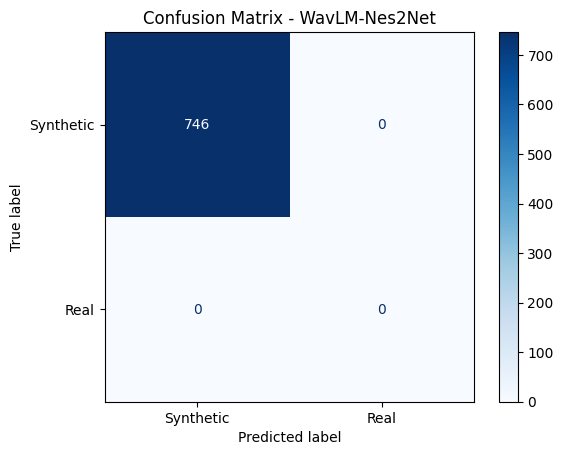


Testing spoof elevenmultilingualv2 tts samples


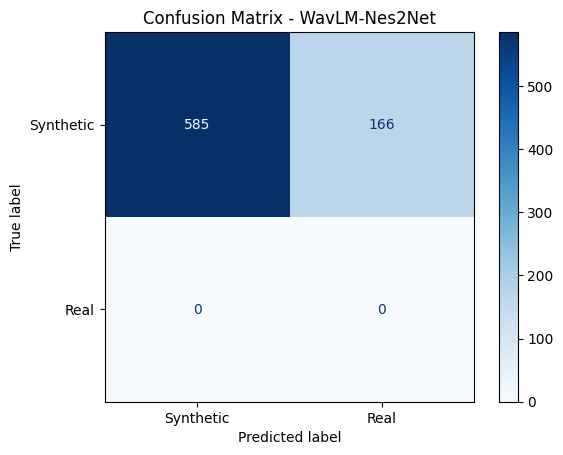


Testing spoof dupdub converted samples


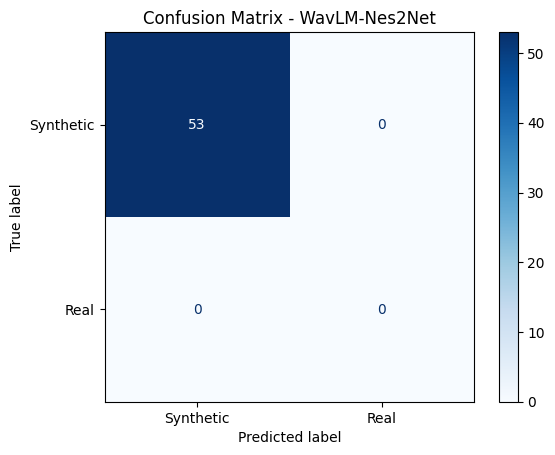


Testing spoof dupdub tts samples


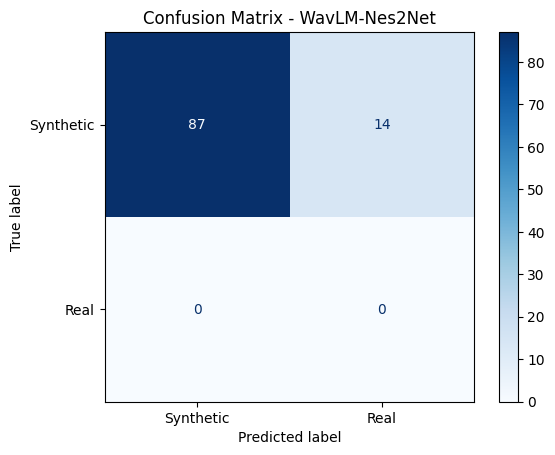


Testing spoof dupdub notindataset tts samples


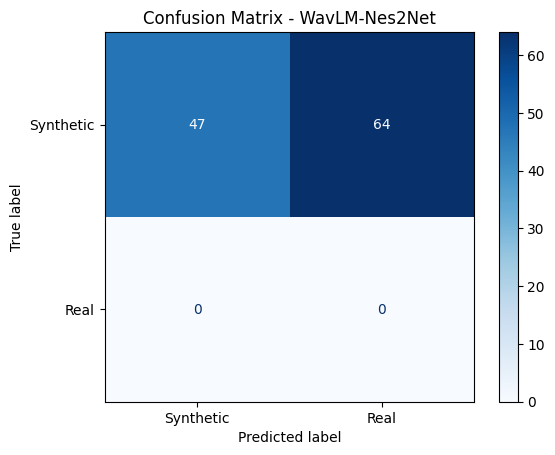


Testing spoof facebookmms converted samples


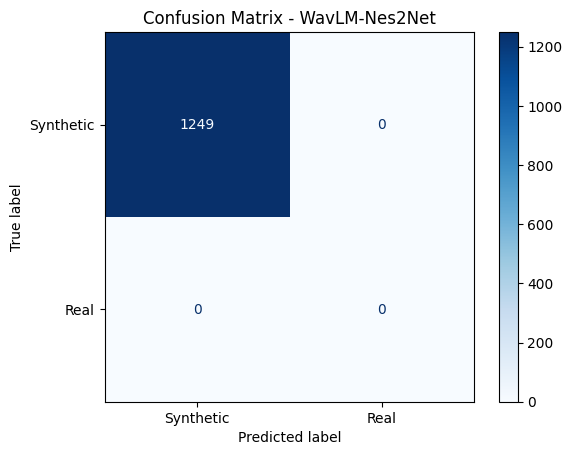


Testing spoof facebookmms tts samples


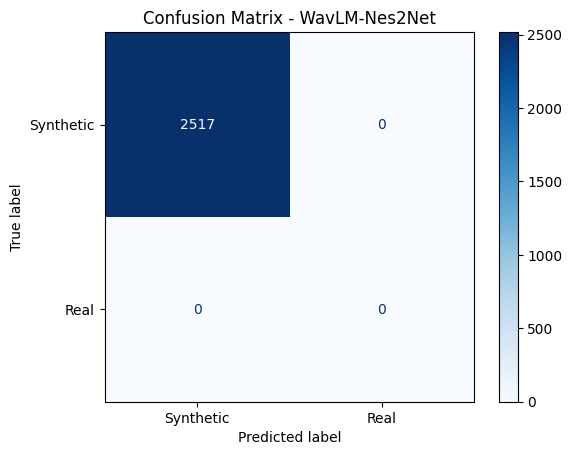


Testing spoof googletts converted samples


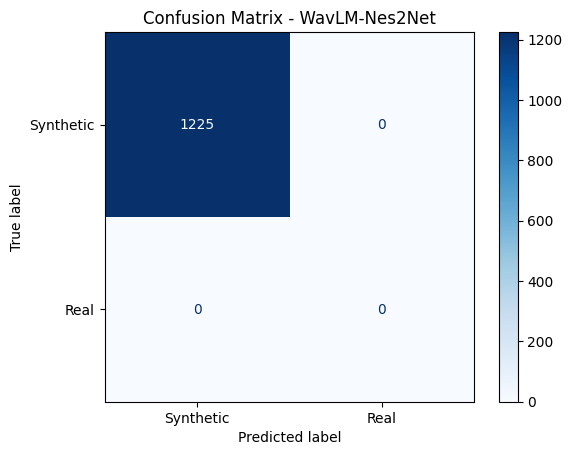


Testing spoof googletts tts samples


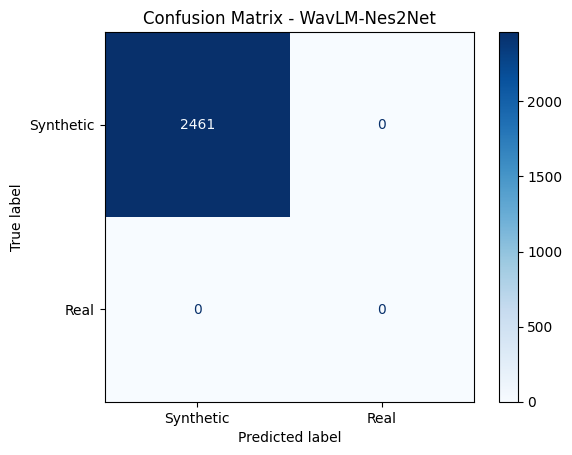


Testing spoof vits converted samples


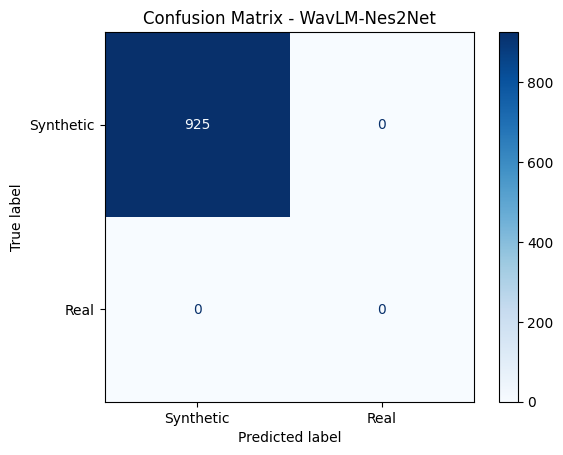


Testing spoof vits tts samples


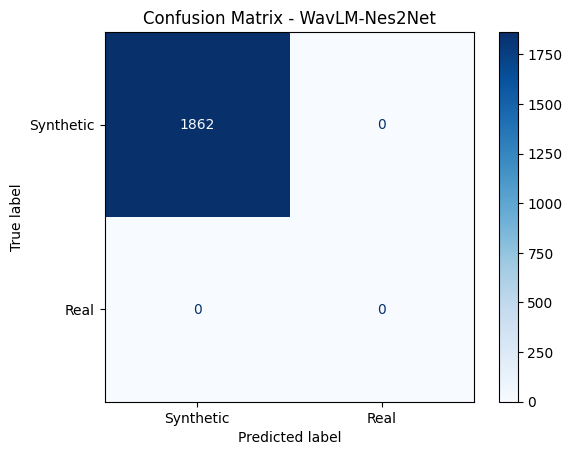


Testing bonafide commonvoice samples


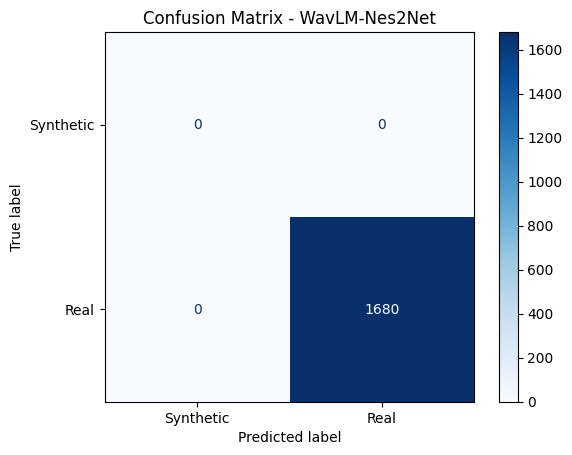


Testing bonafide prosa samples


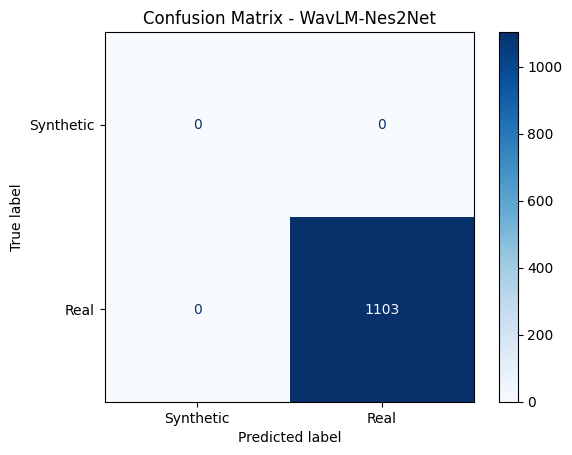


Testing spoof all samples


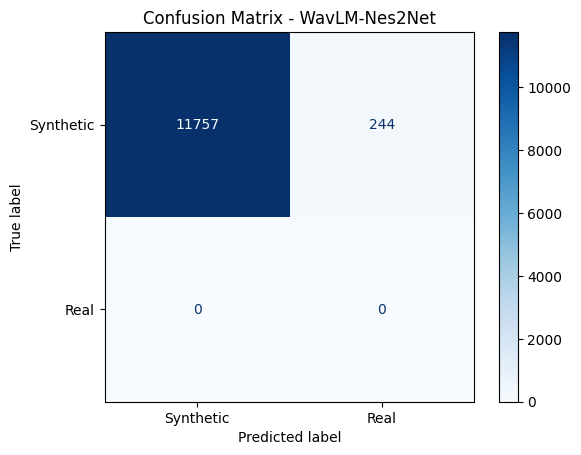


Testing bonafide all samples


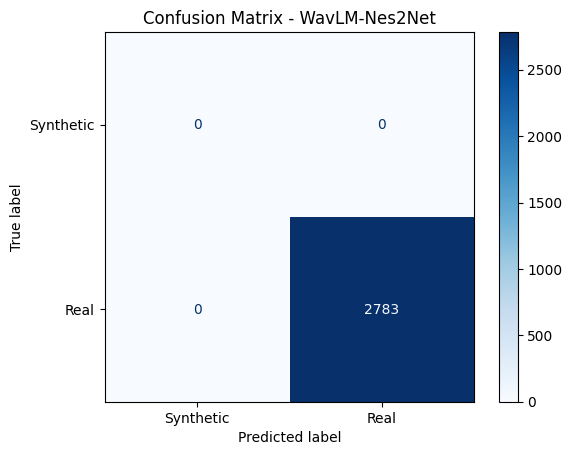


Testing seen all samples
              --> Test Acc: 100.00%
              --> Balanced Acc: 1.0000 | Precision: 1.0000
              --> Recall: 1.0000 | F1: 1.0000 | F2: 1.0000
              --> EER: 0.0000 | actDCF: 1.0000 | minDCF: 0.0000
              --> CLLR: 0.0001


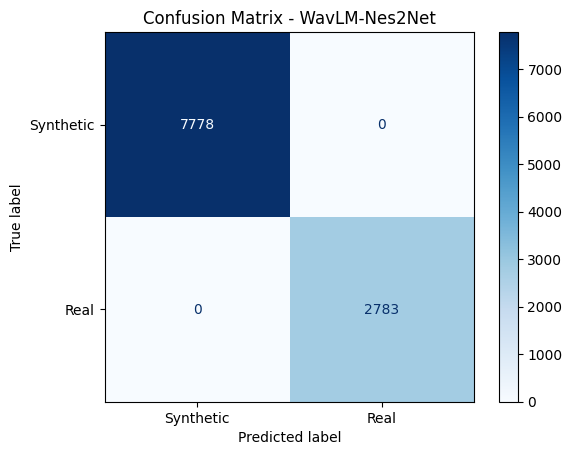


Testing unseen all samples (UID)


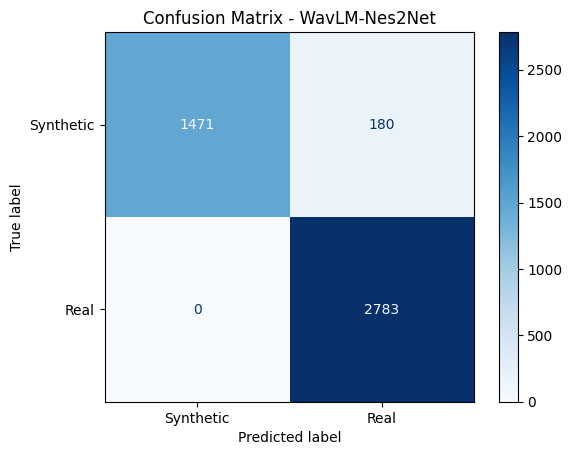


Testing unseen all samples (UID) w/ Google TTS
              --> Test Acc: 96.52%
              --> Balanced Acc: 0.9711 | Precision: 0.9194
              --> Recall: 1.0000 | F1: 0.9580 | F2: 0.9828
              --> EER: 0.0032 | actDCF: 1.0000 | minDCF: 0.0051
              --> CLLR: 0.2607


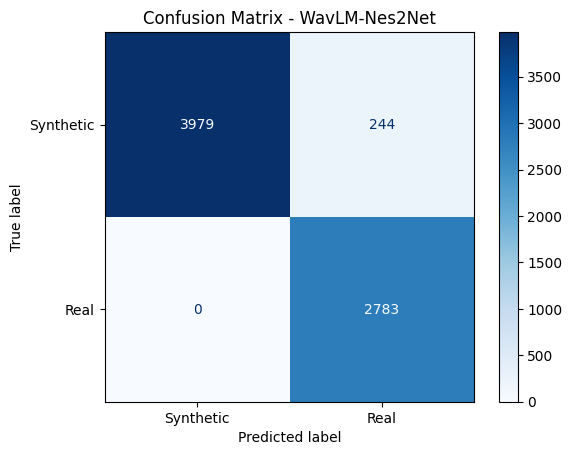


Testing unseen all samples (UnID)
              --> Test Acc: 97.79%
              --> Balanced Acc: 0.7117 | Precision: 0.9775
              --> Recall: 1.0000 | F1: 0.9886 | F2: 0.9954
              --> EER: 0.0180 | actDCF: 1.0000 | minDCF: 0.0248
              --> CLLR: 2.8803


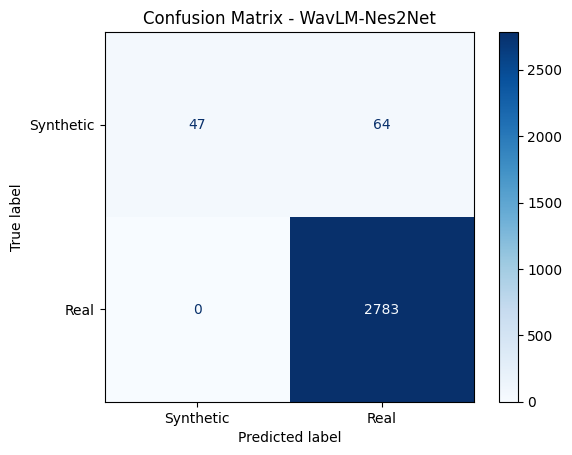

In [3]:
nes2net_model_config = {
    'agg': 'SEA',              # Aggregation method: 'SEA', 'WeightedSum', 'AttM'
    'Nes_ratio': [8, 8],       # Nested Res2Net ratio
    'dilation': 2,             # Dilation factor
    'pool_func': 'mean',       # Pooling function: 'mean' or 'ASTP'
    'SE_ratio': [8],           # SE module ratio
    'cp_path': 'wavlm_large.pt',  # Path to pretrained WavLM model
    'fine_tune_ssl': True      # Whether to fine-tune SSL model
}

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# --- Set up model, optimizer, and scaler ---
model = WavLMNes2Net(nes2net_model_config, device).to(device)
optimizer = Adam(model.parameters(), lr=learning_rate)
scaler = GradScaler()

# --- Load the model ---
start_epoch = load_model_nes2net(
    model, optimizer, scaler,
    path=r"pretrained_weights/waveform/Nes2Net/nes2net_waveform-ep_30-bs_32-lr_1e-06.pth",
    device=device
)

print(f"Loaded checkpoint from epoch {start_epoch}")

# Count parameters
nb_params = sum([param.view(-1).size()[0] for param in model.parameters() if param.requires_grad])
print(f'Number of trainable parameters: {nb_params:,}')

for key, test_sample in nes2net_waveform_test_samples_dataloaders.items():
    print(f"\nTesting {key}")
    if key in main_keys:
        predictions, targets, metrics = test_nes2net(model, test_sample, device=device)
    else:
        predictions = test_nes2net_with_loaders(model, test_sample, device=device)
    torch.cuda.empty_cache()

In [4]:
# Clean up baseline model from GPU memory
print("Cleaning up baseline model from GPU memory...")

# Delete model components explicitly
if hasattr(model, "ssl_model"):
    del model.ssl_model

del model
del optimizer
del scaler

# Force garbage collection
import gc
gc.collect()

# Clear CUDA cache multiple times
torch.cuda.empty_cache()
torch.cuda.synchronize()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

# Print memory info
if torch.cuda.is_available():
    memory_allocated = torch.cuda.memory_allocated() / 1024**3
    memory_reserved = torch.cuda.memory_reserved() / 1024**3
    print(f"GPU memory allocated: {memory_allocated:.2f} GB")
    print(f"GPU memory reserved: {memory_reserved:.2f} GB")

print("GPU memory cleaned successfully!")

Cleaning up baseline model from GPU memory...
GPU memory allocated: 0.00 GB
GPU memory reserved: 0.00 GB
GPU memory cleaned successfully!


# Combined (Diff Pipeline)

In [5]:
# Combined features test samples
nes2net_combined_test_samples = {
    "spoof elevenmultilingualv2 converted samples": [],
    "spoof elevenmultilingualv2 tts samples": [],
    "spoof dupdub converted samples": [],
    "spoof dupdub tts samples": [],
    "spoof dupdub notindataset tts samples": [],
    "spoof facebookmms converted samples": [],
    "spoof facebookmms tts samples": [],
    "spoof googletts converted samples": [],
    "spoof googletts tts samples": [],
    "spoof vits converted samples": [],
    "spoof vits tts samples": [],
    "bonafide commonvoice samples": [],
    "bonafide prosa samples": [],
    
    "spoof all samples": [],
    "bonafide all samples": [],
    
    "seen all samples": [],
    "unseen all samples (UID)": [],
    "unseen all samples (UID) w/ Google TTS": [],
    "unseen all samples (UnID)": [],
}

# Combined feature directories
combined_spoof_elevenmultilingualv2_converted_dir = "test_preprocessed_data/combined/Spoof/Converted/ElevenMultilingualV2"
combined_spoof_elevenmultilingualv2_tts_dir = "test_preprocessed_data/combined/Spoof/TTS/ElevenMultilingualV2"
combined_spoof_dupdub_converted_dir = "test_preprocessed_data/combined/Spoof/Converted/DupDub"
combined_spoof_dupdub_tts_dir = "test_preprocessed_data/combined/Spoof/TTS/DupDub"
combined_spoof_dupdub_notindataset_tts_dir = "test_preprocessed_data/combined/Spoof/TTS/DupDub-NotInDataset"

combined_spoof_facebookmms_converted_dir = "preprocessed_data/combined/Spoof/Converted/FacebookMMS"
combined_spoof_facebookmms_tts_dir = "preprocessed_data/combined/Spoof/TTS/FacebookMMS"
combined_spoof_googletts_converted_dir = "preprocessed_data/combined/Spoof/Converted/GoogleTTS"
combined_spoof_googletts_tts_dir = "preprocessed_data/combined/Spoof/TTS/GoogleTTS"
combined_spoof_vits_converted_dir = "preprocessed_data/combined/Spoof/Converted/VITS"
combined_spoof_vits_tts_dir = "preprocessed_data/combined/Spoof/TTS/VITS"

combined_bonafide_commonvoice_dir = "preprocessed_data/combined/Bonafide/CommonVoice"
combined_bonafide_prosa_dir = "preprocessed_data/combined/Bonafide/Prosa"

# Load combined data (same pattern as waveform, but using CombinedFeatureDataset)
# ElevenMultilingualV2 Converted
if os.path.exists(combined_spoof_elevenmultilingualv2_converted_dir):
    dataset = CombinedFeatureDataset(combined_spoof_elevenmultilingualv2_converted_dir, force_label=0)
    data_list = ListDataset([(features, 0) for features, _ in dataset.samples])
    nes2net_combined_test_samples["spoof elevenmultilingualv2 converted samples"].extend(data_list)
    nes2net_combined_test_samples["spoof all samples"].extend(data_list)
    nes2net_combined_test_samples["unseen all samples (UID)"].extend(data_list)
    nes2net_combined_test_samples["unseen all samples (UID) w/ Google TTS"].extend(data_list)
    print(f"Loaded {len(data_list)} samples from {combined_spoof_elevenmultilingualv2_converted_dir}")
else:
    print(f"Warning: Directory not found: {combined_spoof_elevenmultilingualv2_converted_dir}")

# ElevenMultilingualV2 TTS
if os.path.exists(combined_spoof_elevenmultilingualv2_tts_dir):
    dataset = CombinedFeatureDataset(combined_spoof_elevenmultilingualv2_tts_dir, force_label=0)
    data_list = ListDataset([(features, 0) for features, _ in dataset.samples])
    nes2net_combined_test_samples["spoof elevenmultilingualv2 tts samples"].extend(data_list)
    nes2net_combined_test_samples["spoof all samples"].extend(data_list)
    nes2net_combined_test_samples["unseen all samples (UID)"].extend(data_list)
    nes2net_combined_test_samples["unseen all samples (UID) w/ Google TTS"].extend(data_list)
    print(f"Loaded {len(data_list)} samples from {combined_spoof_elevenmultilingualv2_tts_dir}")

# DupDub Converted
if os.path.exists(combined_spoof_dupdub_converted_dir):
    dataset = CombinedFeatureDataset(combined_spoof_dupdub_converted_dir, force_label=0)
    data_list = ListDataset([(features, 0) for features, _ in dataset.samples])
    nes2net_combined_test_samples["spoof dupdub converted samples"].extend(data_list)
    nes2net_combined_test_samples["spoof all samples"].extend(data_list)
    nes2net_combined_test_samples["unseen all samples (UID)"].extend(data_list)
    nes2net_combined_test_samples["unseen all samples (UID) w/ Google TTS"].extend(data_list)
    print(f"Loaded {len(data_list)} samples from {combined_spoof_dupdub_converted_dir}")

# DupDub TTS
if os.path.exists(combined_spoof_dupdub_tts_dir):
    dataset = CombinedFeatureDataset(combined_spoof_dupdub_tts_dir, force_label=0)
    data_list = ListDataset([(features, 0) for features, _ in dataset.samples])
    nes2net_combined_test_samples["spoof dupdub tts samples"].extend(data_list)
    nes2net_combined_test_samples["spoof all samples"].extend(data_list)
    nes2net_combined_test_samples["unseen all samples (UID)"].extend(data_list)
    nes2net_combined_test_samples["unseen all samples (UID) w/ Google TTS"].extend(data_list)
    print(f"Loaded {len(data_list)} samples from {combined_spoof_dupdub_tts_dir}")

# DupDub NotInDataset TTS
if os.path.exists(combined_spoof_dupdub_notindataset_tts_dir):
    dataset = CombinedFeatureDataset(combined_spoof_dupdub_notindataset_tts_dir, force_label=0)
    data_list = ListDataset([(features, 0) for features, _ in dataset.samples])
    nes2net_combined_test_samples["spoof dupdub notindataset tts samples"].extend(data_list)
    nes2net_combined_test_samples["spoof all samples"].extend(data_list)
    nes2net_combined_test_samples["unseen all samples (UnID)"].extend(data_list)
    nes2net_combined_test_samples["unseen all samples (UID) w/ Google TTS"].extend(data_list)
    print(f"Loaded {len(data_list)} samples from {combined_spoof_dupdub_notindataset_tts_dir}")

# GoogleTTS TTS
if os.path.exists(combined_spoof_googletts_tts_dir):
    dataset = CombinedFeatureDataset(combined_spoof_googletts_tts_dir, force_label=0)
    data = ListDataset([(features, 0) for features, _ in dataset.samples])
    t, v, te = stratified_split(data, splits=(0.7, 0.15, 0.15), seed=seed)
    data_list = ListDataset([data[i] for i in range(len(te))])
    nes2net_combined_test_samples["spoof googletts tts samples"].extend(data_list)
    nes2net_combined_test_samples["spoof all samples"].extend(data_list)
    nes2net_combined_test_samples["unseen all samples (UID) w/ Google TTS"].extend(data_list)
    print(f"Loaded {len(data_list)} samples from {combined_spoof_googletts_tts_dir}")

# Seen datasets - FacebookMMS, GoogleTTS, VITS
for name, dir_path in [
    ("facebookmms converted", combined_spoof_facebookmms_converted_dir),
    ("facebookmms tts", combined_spoof_facebookmms_tts_dir),
    ("googletts converted", combined_spoof_googletts_converted_dir),
    ("vits converted", combined_spoof_vits_converted_dir),
    ("vits tts", combined_spoof_vits_tts_dir)
]:
    if os.path.exists(dir_path):
        dataset = CombinedFeatureDataset(dir_path, force_label=0)
        data = ListDataset([(features, 0) for features, _ in dataset.samples])
        t, v, te = stratified_split(data, splits=(0.7, 0.15, 0.15), seed=seed)
        data_list = ListDataset([data[i] for i in range(len(te))])
        nes2net_combined_test_samples[f"spoof {name} samples"].extend(data_list)
        nes2net_combined_test_samples["spoof all samples"].extend(data_list)
        nes2net_combined_test_samples["seen all samples"].extend(data_list)
        print(f"Loaded {len(data_list)} samples from {dir_path}")

# Bonafide datasets
for name, dir_path in [
    ("commonvoice", combined_bonafide_commonvoice_dir),
    ("prosa", combined_bonafide_prosa_dir)
]:
    if os.path.exists(dir_path):
        dataset = CombinedFeatureDataset(dir_path, force_label=1)
        data = ListDataset([(features, 1) for features, _ in dataset.samples])
        t, v, te = stratified_split(data, splits=(0.7, 0.15, 0.15), seed=seed)
        data_list = ListDataset([data[i] for i in range(len(te))])
        nes2net_combined_test_samples[f"bonafide {name} samples"].extend(data_list)
        nes2net_combined_test_samples["bonafide all samples"].extend(data_list)
        nes2net_combined_test_samples["seen all samples"].extend(data_list)
        nes2net_combined_test_samples["unseen all samples (UID)"].extend(data_list)
        nes2net_combined_test_samples["unseen all samples (UID) w/ Google TTS"].extend(data_list)
        nes2net_combined_test_samples["unseen all samples (UnID)"].extend(data_list)
        print(f"Loaded {len(data_list)} samples from {dir_path}")

print("-----------------------------------------------")
print(f"Total test spoof samples: {len(nes2net_combined_test_samples['spoof all samples'])}")
print(f"Total test bonafide samples: {len(nes2net_combined_test_samples['bonafide all samples'])}")
print("-----------------------------------------------")
print(f"Total seen test spoof samples: {len(nes2net_combined_test_samples['seen all samples'])}")
print(f"Total unseen UID samples: {len(nes2net_combined_test_samples['unseen all samples (UID)'])}")
print(f"Total unseen UnID samples: {len(nes2net_combined_test_samples['unseen all samples (UnID)'])}")
print("-----------------------------------------------")

nes2net_combined_test_samples_dataloaders = {
    key: DataLoader(value, batch_size=batch_size, shuffle=False, num_workers=4)
    for key, value in nes2net_combined_test_samples.items()
}

Skipped 0 files due to NaNs/Infs.
Loaded 746 samples from test_preprocessed_data/combined/Spoof/Converted/ElevenMultilingualV2
Skipped 0 files due to NaNs/Infs.
Loaded 751 samples from test_preprocessed_data/combined/Spoof/TTS/ElevenMultilingualV2
Skipped 0 files due to NaNs/Infs.
Loaded 53 samples from test_preprocessed_data/combined/Spoof/Converted/DupDub
Skipped 0 files due to NaNs/Infs.
Loaded 101 samples from test_preprocessed_data/combined/Spoof/TTS/DupDub
Skipped 0 files due to NaNs/Infs.
Loaded 111 samples from test_preprocessed_data/combined/Spoof/TTS/DupDub-NotInDataset
Skipped 0 files due to NaNs/Infs.
Loaded 2461 samples from preprocessed_data/combined/Spoof/TTS/GoogleTTS
Skipped 0 files due to NaNs/Infs.
Loaded 1249 samples from preprocessed_data/combined/Spoof/Converted/FacebookMMS
Skipped 0 files due to NaNs/Infs.
Loaded 2517 samples from preprocessed_data/combined/Spoof/TTS/FacebookMMS
Skipped 0 files due to NaNs/Infs.
Loaded 1225 samples from preprocessed_data/combined

## WavLM-Nes2Net (Diff Pipeline)

Using device: cuda
Loading pretrained WavLM model from: wavlm_large.pt
Successfully loaded WavLM model via s3prl hub
WavLM-Nes2Net (Different Pipeline) model initialized
Loaded model from pretrained_weights/diff_pipeline/Nes2Net/nes2net_diff_pipeline-ep_30-bs_32-lr_1e-06.pth (epoch 29)
Loaded checkpoint from epoch 29
Number of trainable parameters: 315,765,922

Testing spoof elevenmultilingualv2 converted samples


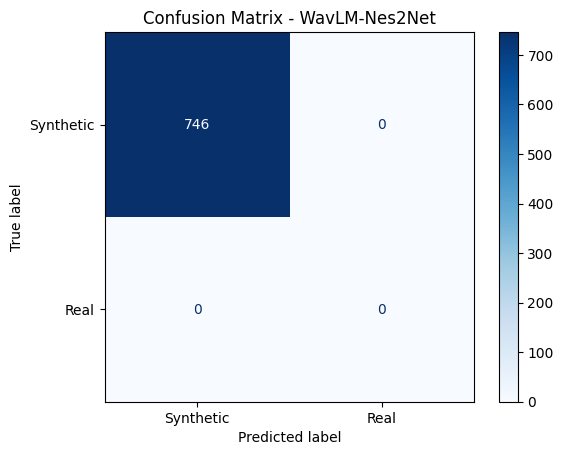


Testing spoof elevenmultilingualv2 tts samples


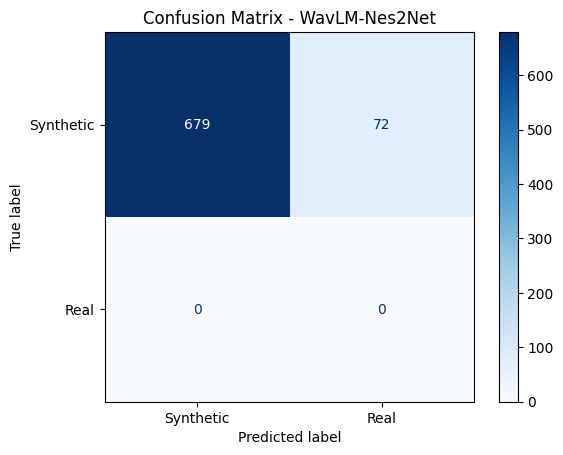


Testing spoof dupdub converted samples


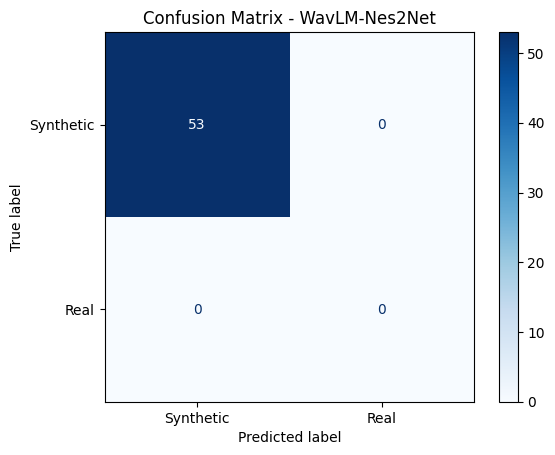


Testing spoof dupdub tts samples


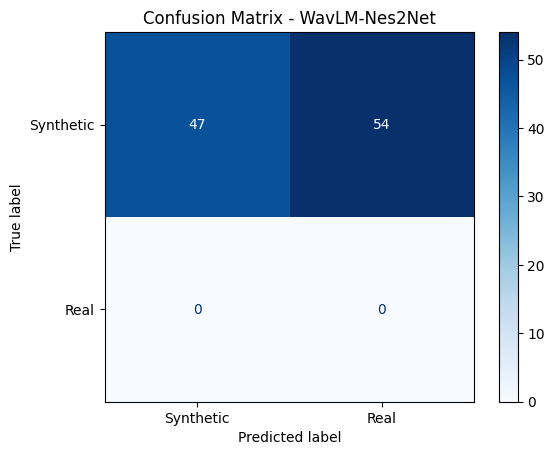


Testing spoof dupdub notindataset tts samples


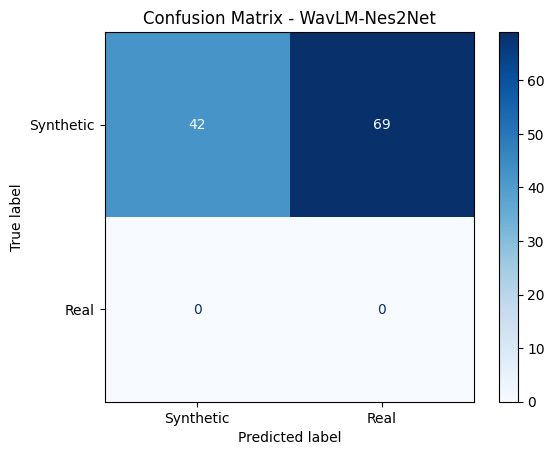


Testing spoof facebookmms converted samples


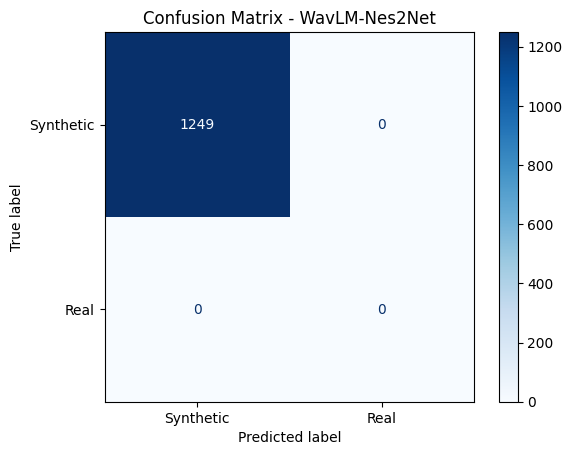


Testing spoof facebookmms tts samples


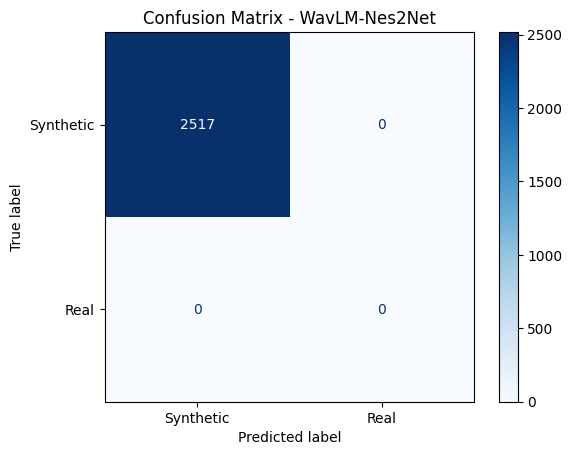


Testing spoof googletts converted samples


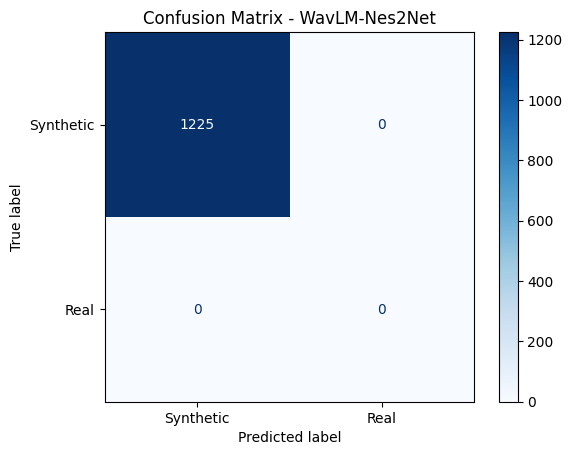


Testing spoof googletts tts samples


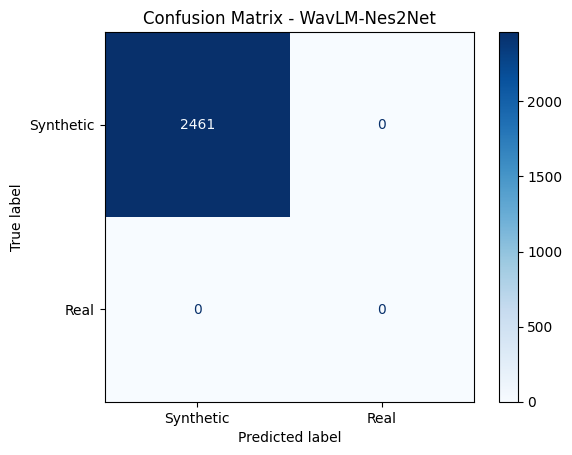


Testing spoof vits converted samples


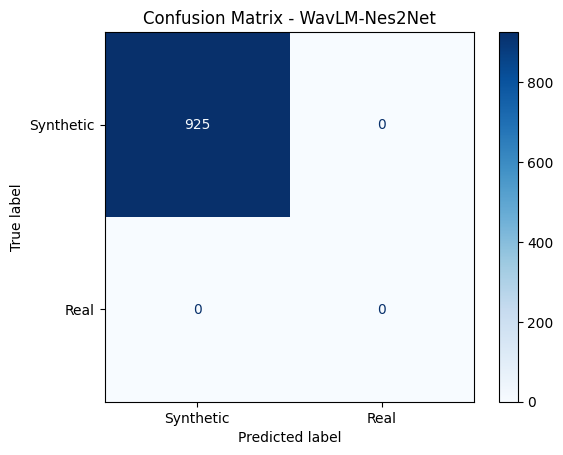


Testing spoof vits tts samples


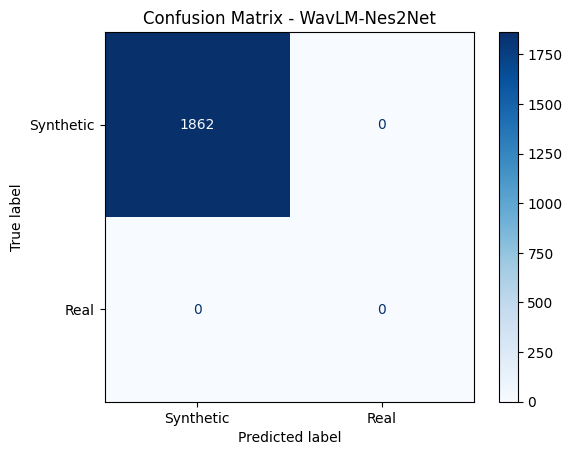


Testing bonafide commonvoice samples


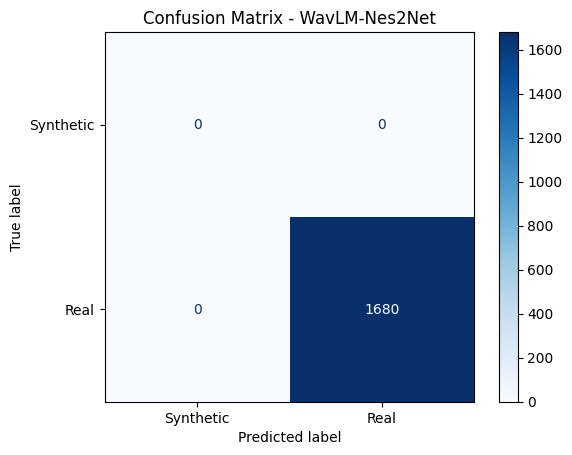


Testing bonafide prosa samples


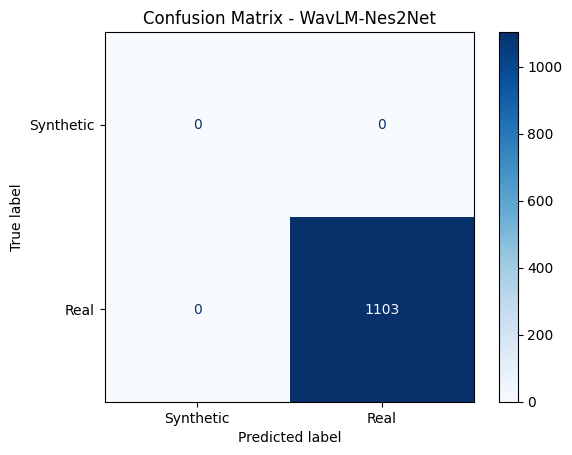


Testing spoof all samples


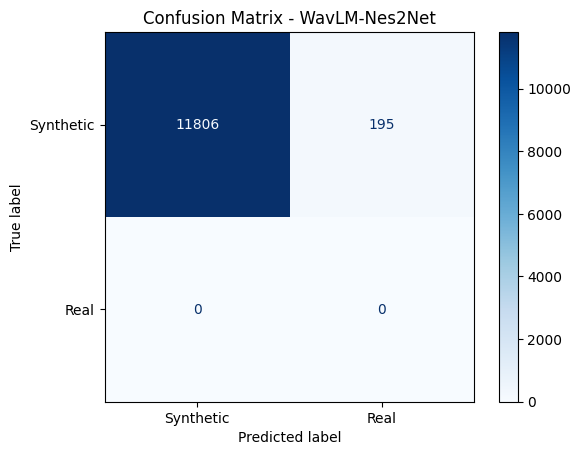


Testing bonafide all samples


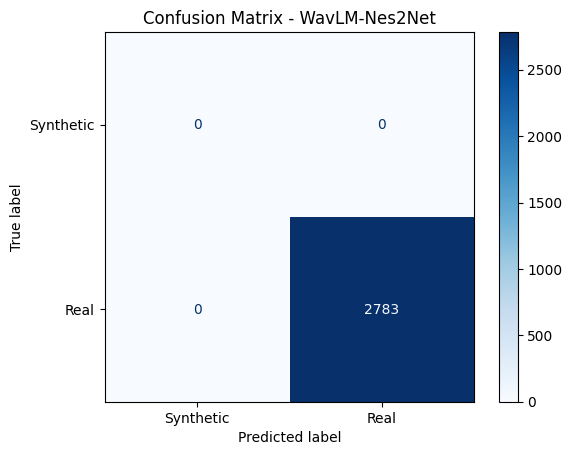


Testing seen all samples
              --> Test Acc: 100.00%
              --> Balanced Acc: 1.0000 | Precision: 1.0000
              --> Recall: 1.0000 | F1: 1.0000 | F2: 1.0000
              --> EER: 0.0000 | actDCF: 1.0000 | minDCF: 0.0000
              --> CLLR: 0.0004


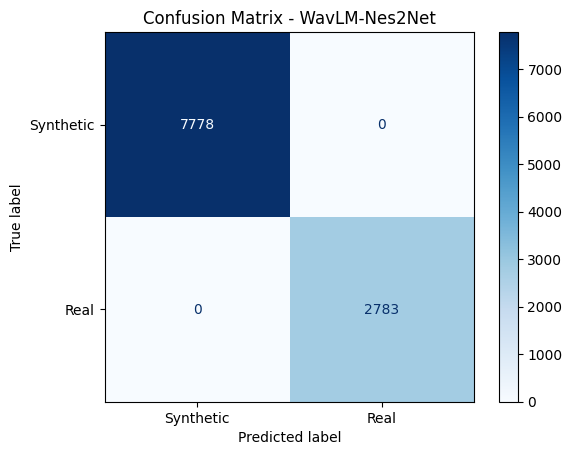


Testing unseen all samples (UID)


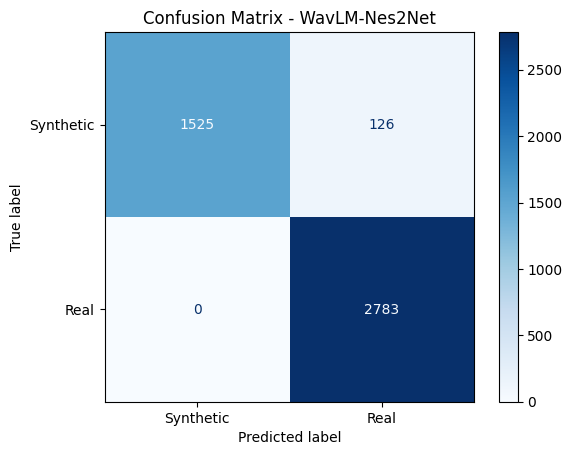


Testing unseen all samples (UID) w/ Google TTS
              --> Test Acc: 97.22%
              --> Balanced Acc: 0.9769 | Precision: 0.9345
              --> Recall: 1.0000 | F1: 0.9662 | F2: 0.9862
              --> EER: 0.0040 | actDCF: 1.0000 | minDCF: 0.0066
              --> CLLR: 0.1487


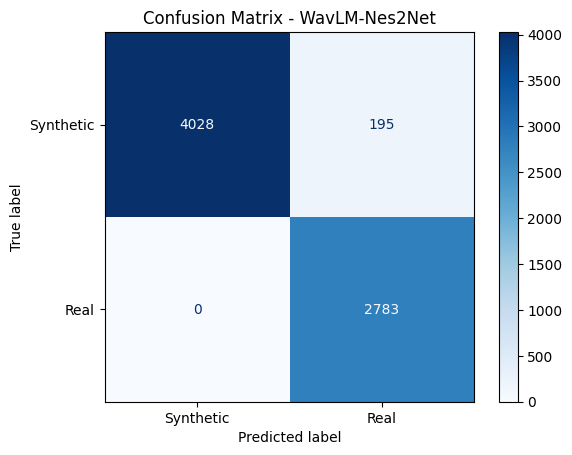


Testing unseen all samples (UnID)
              --> Test Acc: 97.62%
              --> Balanced Acc: 0.6892 | Precision: 0.9758
              --> Recall: 1.0000 | F1: 0.9878 | F2: 0.9951
              --> EER: 0.0180 | actDCF: 1.0000 | minDCF: 0.0328
              --> CLLR: 2.6286


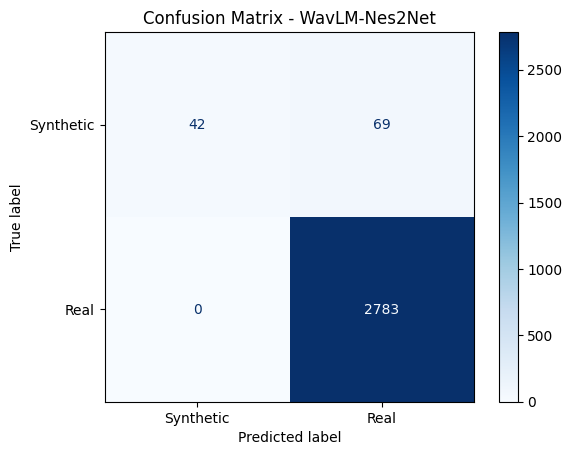

In [6]:
# Import diff pipeline model
from classes.models.Nes2Net.model_Nes2Net_diff_pipeline import WavLMNes2NetDiffPipeline

nes2net_diff_pipeline_model_config = {
    'agg': 'SEA',              # Aggregation method: 'SEA', 'WeightedSum', 'AttM'
    'Nes_ratio': [8, 8],       # Nested Res2Net ratio
    'dilation': 2,             # Dilation factor
    'pool_func': 'mean',       # Pooling function: 'mean' or 'ASTP'
    'SE_ratio': [8],           # SE module ratio
    'cp_path': 'wavlm_large.pt',  # Path to pretrained WavLM model
    'fine_tune_ssl': True,     # Whether to fine-tune SSL model
    'nb_patho_features': 24    # Number of pathological features
}

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# --- Set up model, optimizer, and scaler ---
model = WavLMNes2NetDiffPipeline(nes2net_diff_pipeline_model_config, device).to(device)
optimizer = Adam(model.parameters(), lr=learning_rate)
scaler = GradScaler()

# --- Load the model ---
start_epoch = load_model_nes2net(
    model, optimizer, scaler,
    path=r"pretrained_weights/diff_pipeline/Nes2Net/nes2net_diff_pipeline-ep_30-bs_32-lr_1e-06.pth",
    device=device
)

print(f"Loaded checkpoint from epoch {start_epoch}")

# Count parameters
nb_params = sum([param.view(-1).size()[0] for param in model.parameters() if param.requires_grad])
print(f'Number of trainable parameters: {nb_params:,}')

for key, test_sample in nes2net_combined_test_samples_dataloaders.items():
    print(f"\nTesting {key}")
    if key in main_keys:
        predictions, targets, metrics = test_nes2net(model, test_sample, device=device)
    else:
        predictions = test_nes2net_with_loaders(model, test_sample, device=device)
    torch.cuda.empty_cache()